# Feature Engineering

각 피처 그룹별 변환 방법 및 실험 결과 정리

In [4]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
import lightgbm as lgb
import matplotlib.font_manager as fm

warnings.filterwarnings('ignore')

# 테마와 스타일 적용
sns.set_style("whitegrid")
plt.style.use('seaborn-v0_8') # 시각화 스타일 설정

# 한글폰트와 마이너스 깨짐 방지 덮어씌우기
font_path = "/System/Library/Fonts/Supplemental/AppleGothic.ttf"
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["axes.unicode_minus"] = False

TRAIN_PATH = '../data/train.csv'
SEED = 42

Q_COLS  = [f'Q{chr(ord("a")+i)}A' for i in range(20)]
QE_COLS = [f'Q{chr(ord("a")+i)}E' for i in range(20)]
TP_COLS = [f'tp{str(i).zfill(2)}' for i in range(1, 11)]
WR_COLS = [f'wr_{str(i).zfill(2)}' for i in range(1, 14)]
WF_COLS = [f'wf_{str(i).zfill(2)}' for i in range(1, 4)]

# 역문항 10개 (Spearman 상관분석 기반)
REVERSE_Q = ['QaA','QdA','QeA','QfA','QgA','QiA','QkA','QnA','QqA','QrA']
CAT_COLS  = ['age_group','education','engnat','gender','hand','married','race','religion','urban']

df = pd.read_csv(TRAIN_PATH)
df['voted'] = (df['voted'] == 1).astype(int)
if 'index' in df.columns: df = df.drop(columns=['index'])

# familysize 이상치 제거
print(f'familysize > 50 이상치: {(df["familysize"] > 50).sum()}행')
df = df[df['familysize'] <= 50].reset_index(drop=True)

print(f'shape: {df.shape}')
print(f'voted 분포: {df["voted"].value_counts().to_dict()}')

familysize > 50 이상치: 3행
shape: (45529, 77)
voted 분포: {0: 24897, 1: 20632}


## 1. MACH-IV 역문항 처리

- 마키아벨리즘 척도(Q1~Q20) 중 역방향 문항 10개: `6 - 원점수`
- **수정 전**: 4개만 역코딩 / **수정 후**: Spearman 상관분석으로 10개 확인
- 역문항: QaA, QdA, QeA, QfA, QgA, QiA, QkA, QnA, QqA, QrA

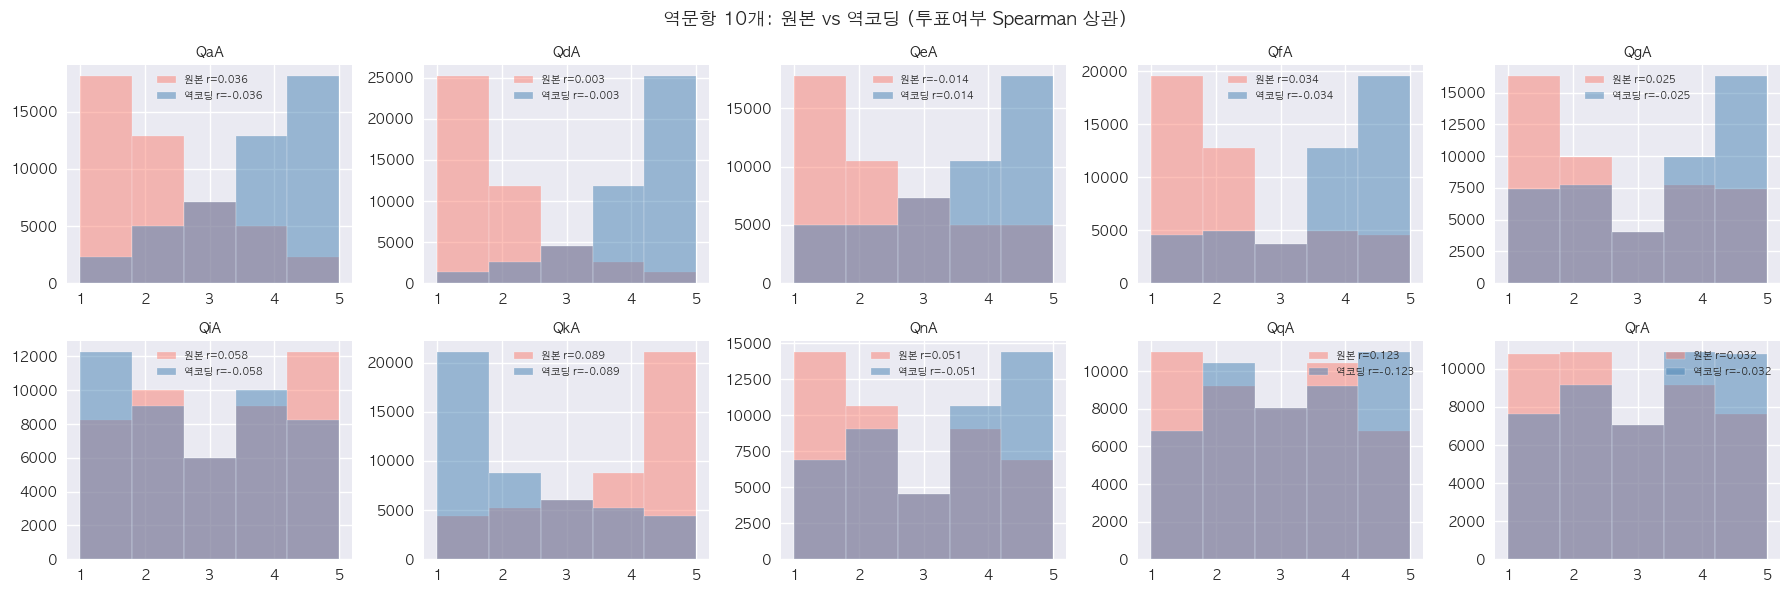

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
axes = axes.flatten()

for i, col in enumerate(REVERSE_Q):
    before = df[col]
    after  = 6 - df[col]
    r_before = before.corr(df['voted'], method='spearman')
    r_after  = after.corr(df['voted'], method='spearman')
    axes[i].hist(before, alpha=0.5, bins=5, label=f'원본 r={r_before:.3f}', color='salmon')
    axes[i].hist(after,  alpha=0.5, bins=5, label=f'역코딩 r={r_after:.3f}', color='steelblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=7)

plt.suptitle('역문항 10개: 원본 vs 역코딩 (투표여부 Spearman 상관)', fontsize=13)
plt.tight_layout()
plt.show()

## 2. mach_score 및 MACH 파생 피처

- `mach_score`: 역문항 보정 후 Q1~Q20 평균
- `q_response_std`: 응답 표준편차 (응답 일관성)
- `q_extreme_ratio`: 1 또는 5 극단 응답 비율

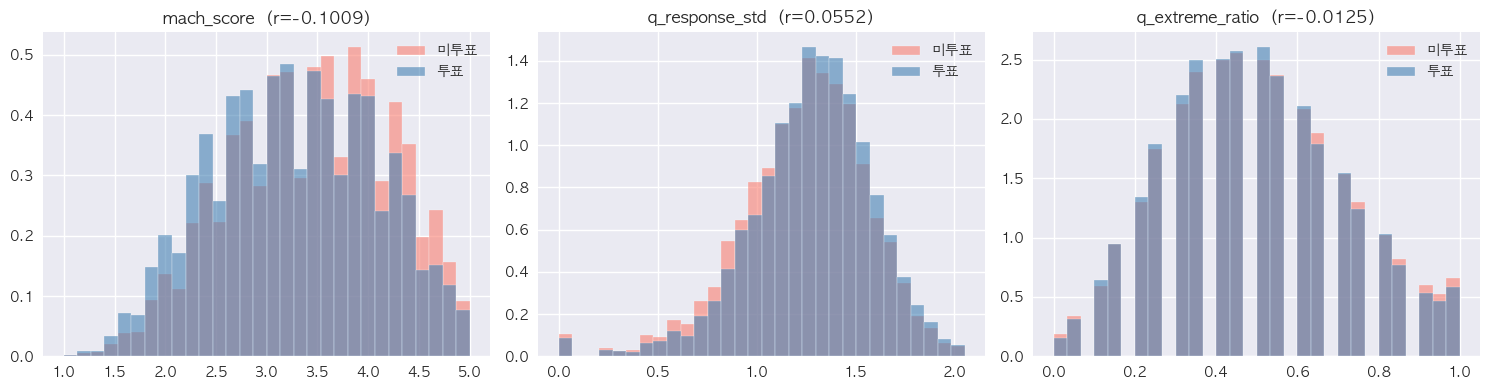

mach_score            : Spearman r = -0.10090
q_response_std        : Spearman r = 0.05516
q_extreme_ratio       : Spearman r = -0.01253


In [6]:
d = df.copy()
for col in REVERSE_Q:
    d[col] = 6 - d[col]

d['mach_score']      = d[Q_COLS].mean(axis=1)
d['q_response_std']  = d[Q_COLS].std(axis=1)
d['q_extreme_ratio'] = ((d[Q_COLS]==1)|(d[Q_COLS]==5)).sum(axis=1) / len(Q_COLS)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['mach_score','q_response_std','q_extreme_ratio']):
    for v, label, color in [(0,'미투표','salmon'), (1,'투표','steelblue')]:
        ax.hist(d[d['voted']==v][col], bins=30, alpha=0.6,
                label=label, color=color, density=True)
    r = d[col].corr(d['voted'], method='spearman')
    ax.set_title(f'{col}  (r={r:.4f})')
    ax.legend()

plt.tight_layout()
plt.show()

for col in ['mach_score','q_response_std','q_extreme_ratio']:
    r = d[col].corr(d['voted'], method='spearman')
    print(f'{col:<22}: Spearman r = {r:.5f}')

## 3. 어휘력 피처 (wr / wf)

- `vocab_real`: wr_01~wr_13 합계 (실제 단어 인식)
- `vocab_fake`: wf_01~wf_03 합계 (가짜 단어에 속음)
- `vocab_score`: real - fake×2 (패널티 보정)
- `vocab_accuracy`: real / (real + fake + ε)

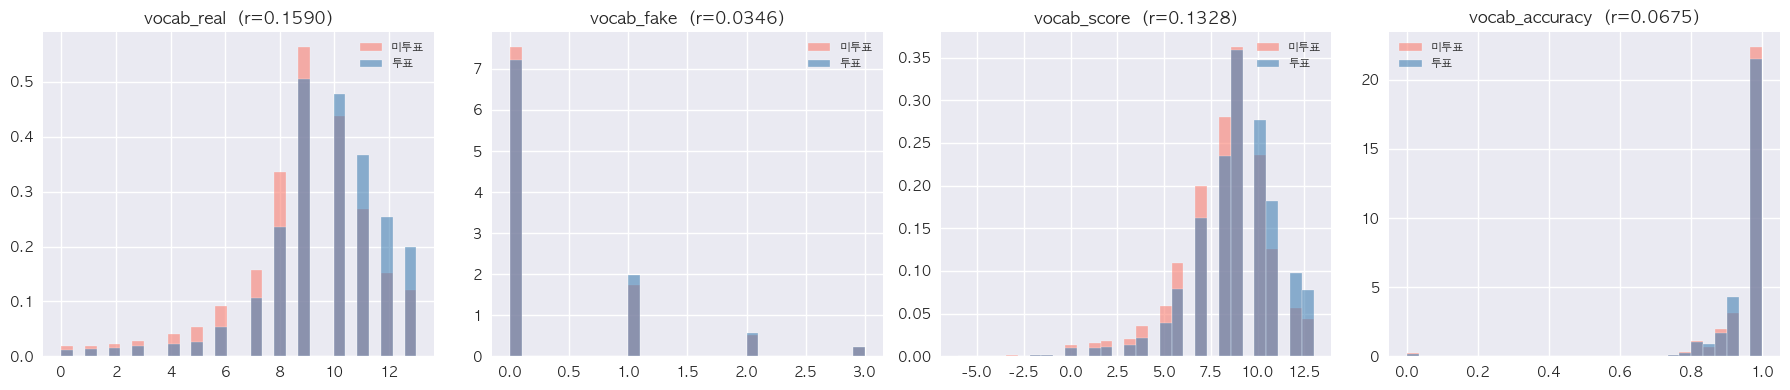

vocab_real          : Spearman r = 0.15896
vocab_fake          : Spearman r = 0.03457
vocab_score         : Spearman r = 0.13283
vocab_accuracy      : Spearman r = 0.06745


In [7]:
avail_wr = [c for c in WR_COLS if c in d.columns]
avail_wf = [c for c in WF_COLS if c in d.columns]

d['vocab_real']     = d[avail_wr].sum(axis=1)
d['vocab_fake']     = d[avail_wf].sum(axis=1)
d['vocab_score']    = d['vocab_real'] - d['vocab_fake'] * 2
d['vocab_accuracy'] = d['vocab_real'] / (d['vocab_real'] + d['vocab_fake'] + 1e-6)

vocab_cols = ['vocab_real','vocab_fake','vocab_score','vocab_accuracy']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, vocab_cols):
    for v, label, color in [(0,'미투표','salmon'), (1,'투표','steelblue')]:
        ax.hist(d[d['voted']==v][col], bins=30, alpha=0.6,
                label=label, color=color, density=True)
    r = d[col].corr(d['voted'], method='spearman')
    ax.set_title(f'{col}  (r={r:.4f})')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

for col in vocab_cols:
    r = d[col].corr(d['voted'], method='spearman')
    print(f'{col:<20}: Spearman r = {r:.5f}')

## 4. QE 응답시간 → delay_root10

- QE 20개 raw: heavy-tail 분포
- **5개 요약통계** 대신 **delay_root10** 단일 피처 사용
- `delay_root10 = sum(QE_COLS).clip(0) ** 0.1`

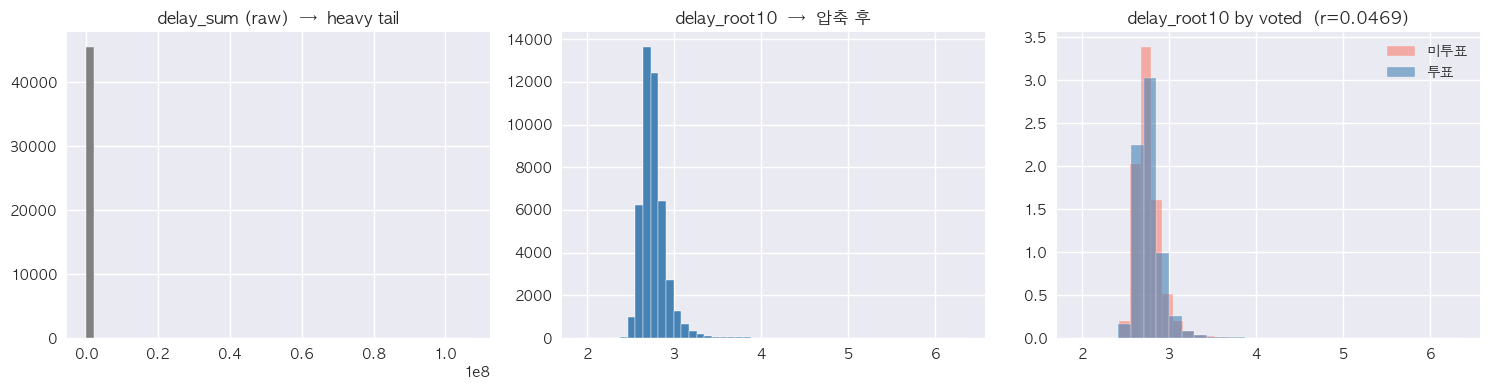

delay_root10 Spearman r = 0.04694


In [8]:
avail_qe = [c for c in QE_COLS if c in d.columns]

delay_sum = d[avail_qe].sum(axis=1).clip(lower=0)
d['delay_root10'] = np.power(delay_sum, 0.1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(delay_sum, bins=50, color='gray')
axes[0].set_title('delay_sum (raw)  →  heavy tail')

axes[1].hist(d['delay_root10'], bins=50, color='steelblue')
axes[1].set_title('delay_root10  →  압축 후')

for v, label, color in [(0,'미투표','salmon'), (1,'투표','steelblue')]:
    axes[2].hist(d[d['voted']==v]['delay_root10'], bins=30,
                 alpha=0.6, label=label, color=color, density=True)
r = d['delay_root10'].corr(d['voted'], method='spearman')
axes[2].set_title(f'delay_root10 by voted  (r={r:.4f})')
axes[2].legend()

plt.tight_layout()
plt.show()
print(f'delay_root10 Spearman r = {r:.5f}')

## 5. tp 컬럼 처리

- 0=무응답, 7=해당없음 → **NaN 변환 전에** 파생 피처 생성 (순서 중요)
- `tp_notapplicable_cnt`: 7인 항목 수
- `tp_missing_cnt`: 0인 항목 수

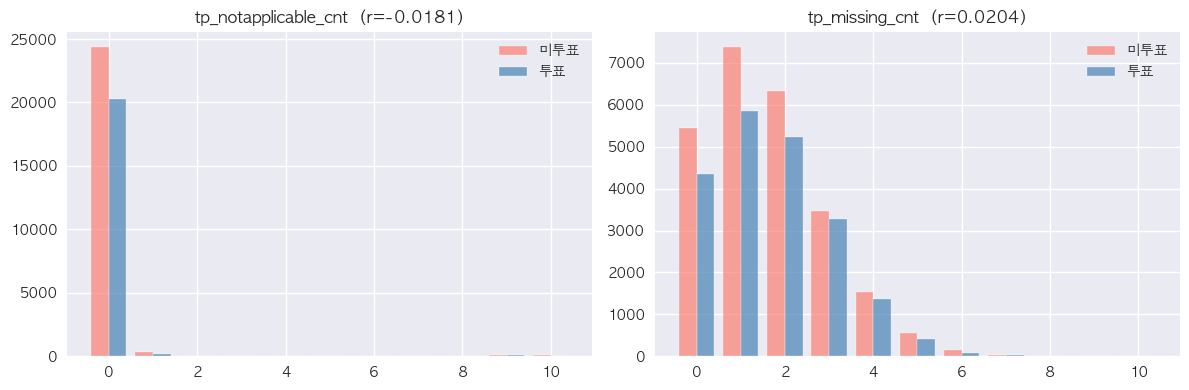

tp 컬럼별 결측/해당없음 비율 (%):
tp01    11.1
tp02    12.6
tp03    26.2
tp04    12.7
tp05    35.3
tp06    20.2
tp07    22.3
tp08     7.9
tp09    20.0
tp10     4.0


In [9]:
avail_tp = [c for c in TP_COLS if c in d.columns]

d['tp_notapplicable_cnt'] = (d[avail_tp] == 7).sum(axis=1)
d['tp_missing_cnt']       = (d[avail_tp] == 0).sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['tp_notapplicable_cnt','tp_missing_cnt']):
    for v, label, color in [(0,'미투표','salmon'), (1,'투표','steelblue')]:
        counts = d[d['voted']==v][col].value_counts().sort_index()
        ax.bar(counts.index + (0.2 if v else -0.2), counts.values,
               width=0.4, alpha=0.7, label=label, color=color)
    r = d[col].corr(d['voted'], method='spearman')
    ax.set_title(f'{col}  (r={r:.4f})')
    ax.legend()

plt.tight_layout()
plt.show()

# NaN 비율
na_count = (d[avail_tp] == 0).sum() + (d[avail_tp] == 7).sum()
print('tp 컬럼별 결측/해당없음 비율 (%):')
print((na_count / len(d) * 100).round(1).to_string())

## 6. familysize 처리

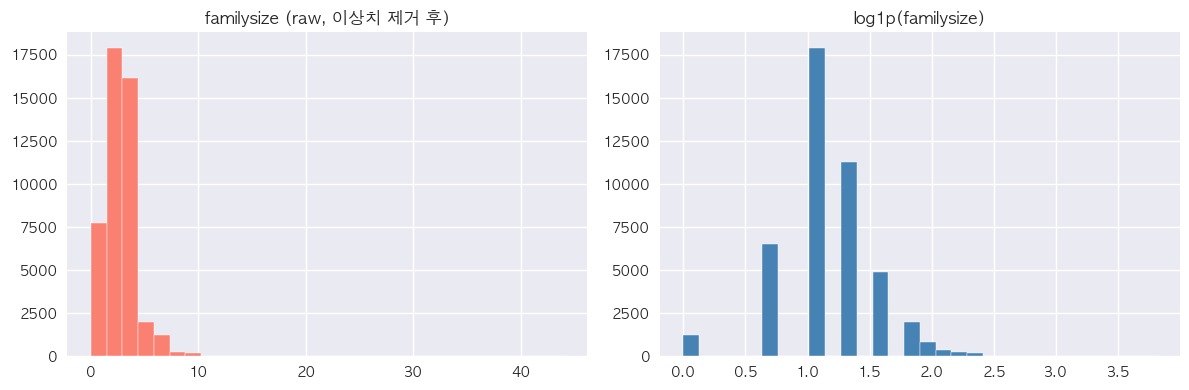

familysize raw    Spearman r = 0.03429
log1p(familysize) Spearman r = 0.03429


In [10]:
raw_fs = df['familysize']
log_fs = np.log1p(raw_fs.clip(lower=0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(raw_fs, bins=30, color='salmon')
axes[0].set_title('familysize (raw, 이상치 제거 후)')
axes[1].hist(log_fs, bins=30, color='steelblue')
axes[1].set_title('log1p(familysize)')
plt.tight_layout()
plt.show()

r_raw = raw_fs.corr(df['voted'], method='spearman')
r_log = log_fs.corr(df['voted'], method='spearman')
print(f'familysize raw    Spearman r = {r_raw:.5f}')
print(f'log1p(familysize) Spearman r = {r_log:.5f}')

## 7. 전체 파이프라인 적용 후 LGBM 피처 중요도

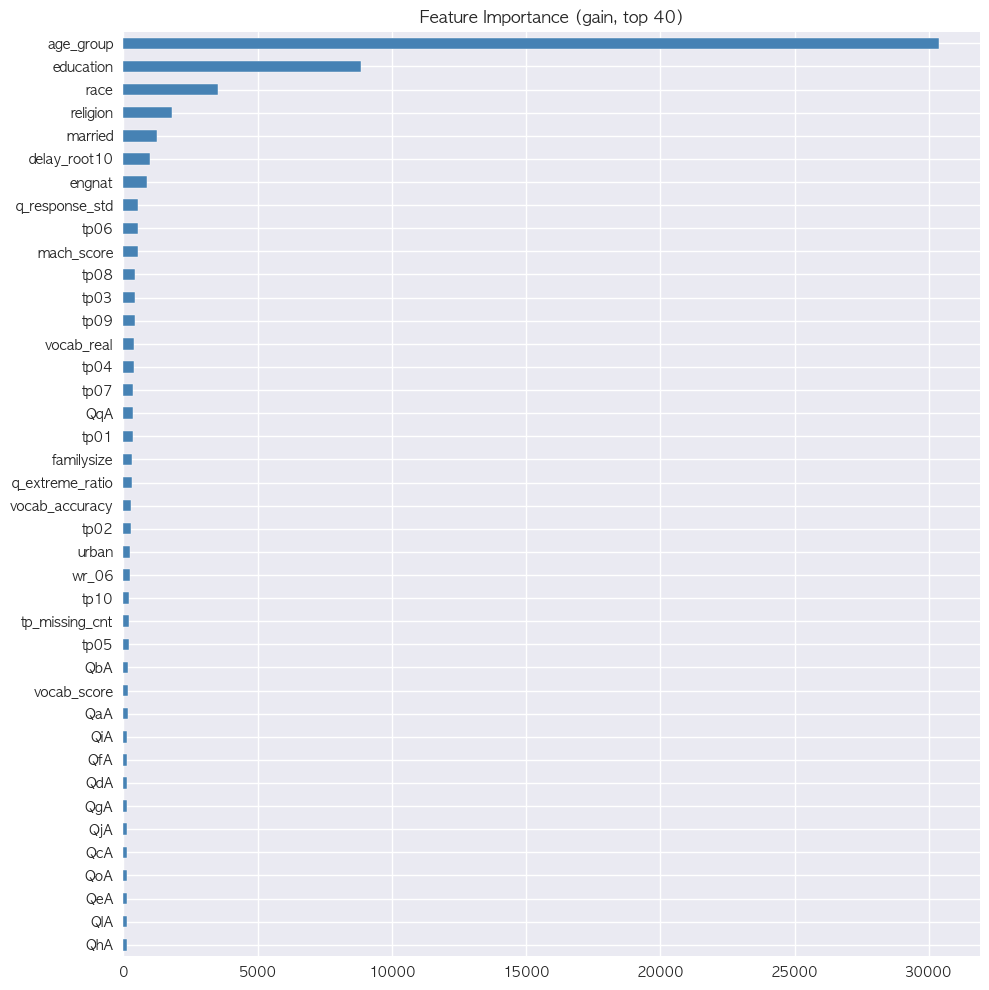

Top 20:
age_group          30380.380195
education           8847.447851
race                3518.347216
religion            1814.698716
married             1239.824905
delay_root10         985.786462
engnat               893.114913
q_response_std       559.090515
tp06                 537.712306
mach_score           528.846904
tp08                 445.476544
tp03                 432.743715
tp09                 429.706878
vocab_real           404.369335
tp04                 402.214140
tp07                 365.288952
QqA                  357.376294
tp01                 343.562140
familysize           332.816927
q_extreme_ratio      320.495386


In [11]:
def build_features(raw):
    d = raw.copy()
    avail_tp = [c for c in TP_COLS if c in d.columns]
    d['tp_notapplicable_cnt'] = (d[avail_tp] == 7).sum(axis=1)
    d['tp_missing_cnt']       = (d[avail_tp] == 0).sum(axis=1)
    for col in avail_tp:
        d[col] = d[col].replace({0: np.nan, 7: np.nan})
    for col in ['education','engnat','hand','married','urban']:
        if col in d.columns: d[col] = d[col].replace(0, np.nan)
    for col in REVERSE_Q:
        if col in d.columns: d[col] = 6 - d[col]
    avail_q = [c for c in Q_COLS if c in d.columns]
    d['mach_score']      = d[avail_q].mean(axis=1)
    d['q_response_std']  = d[avail_q].std(axis=1)
    d['q_extreme_ratio'] = ((d[avail_q]==1)|(d[avail_q]==5)).sum(axis=1)/len(avail_q)
    avail_wr = [c for c in WR_COLS if c in d.columns]
    avail_wf = [c for c in WF_COLS if c in d.columns]
    d['vocab_real']     = d[avail_wr].sum(axis=1)
    d['vocab_fake']     = d[avail_wf].sum(axis=1)
    d['vocab_score']    = d['vocab_real'] - d['vocab_fake'] * 2
    d['vocab_accuracy'] = d['vocab_real'] / (d['vocab_real'] + d['vocab_fake'] + 1e-6)
    avail_qe = [c for c in QE_COLS if c in d.columns]
    d['delay_root10'] = np.power(d[avail_qe].sum(axis=1).clip(lower=0), 0.1)
    d = d.drop(columns=avail_qe)
    if 'familysize' in d.columns:
        d['familysize'] = np.log1p(d['familysize'].clip(lower=0))
    return d

raw = pd.read_csv(TRAIN_PATH)
raw['voted'] = (raw['voted'] == 1).astype(int)
if 'index' in raw.columns: raw = raw.drop(columns=['index'])
raw = raw[raw['familysize'] <= 50].reset_index(drop=True)
feat = build_features(raw)

y = feat['voted'].values
X = feat.drop(columns=['voted'])
for col in CAT_COLS:
    if col in X.columns: X[col] = X[col].astype('category')

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
fi_list = []
params = dict(objective='binary', metric='auc', num_leaves=31,
              learning_rate=0.1, scale_pos_weight=1.20665, verbose=-1)

for tr, va in skf.split(X, y):
    m = lgb.train(params,
                  lgb.Dataset(X.iloc[tr], label=y[tr]),
                  num_boost_round=200,
                  valid_sets=[lgb.Dataset(X.iloc[va], label=y[va])],
                  callbacks=[lgb.early_stopping(20, verbose=False),
                              lgb.log_evaluation(9999)])
    fi_list.append(pd.Series(m.feature_importance('gain'), index=X.columns))

fi = pd.concat(fi_list, axis=1).mean(axis=1).sort_values(ascending=False)

plt.figure(figsize=(10, 10))
fi.head(40).plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title('Feature Importance (gain, top 40)')
plt.tight_layout()
plt.show()

print('Top 20:')
print(fi.head(20).to_string())

## 8. 실험 결론 요약

| 실험 | 결과 | 판단 |
|------|------|------|
| 역문항 4개 → 10개 | mach_score 정확도 향상 | ✅ 적용 |
| QE 5개 요약통계 → delay_root10 | 단일 피처가 더 효과적 | ✅ 적용 |
| familysize log1p + 이상치(>50) 제거 | 분포 정규화 | ✅ 적용 |
| tp 파생 피처 (notapplicable/missing cnt) | 결측 패턴 정보 보존 | ✅ 적용 |
| 상관계수 기반 피처 제거 | OOF AUC -0.019049 | ❌ 금지 |
| QA PCA 치환 | 아이템 레벨 패턴 소실 | ❌ 금지 |
| Big5 추가 FE | OOF AUC -0.000331 | ❌ 금지 |